Im nachfolgenden Code habe ich BERT verwendet, um die Wahrscheinlichkeit von Einwürfen / "interruptions" satzweise in Texten vorherzusagen. Ich habe es nicht speziell auf diesen Task finegetuned, um mir erstmal ein Bild zu machen, was das generische Modell so kann. Den Code habe ich so kommentiert, dass verständlich wird, was da passiert. Ich habe außerdem bereits bekannte Codeabschnitte, die ich in den vorigen Notebooks kommentiert habe, ausgelassen.

Die Visualisierung am Ende ist sehr interessant, wenn man das finetuning im Hinterkopf hat. Es wird das Spektrums der vorhergesagten Wahrscheinlichkeiten, sowie der Index des jeweiligen Satzes in einem Graphen visualisiert. Die vorhergesagten Wahrscheinlichkeiten schwanken um 0,5. Das bedeutet, dass sich das Modell in den meisten Fällen nicht sicher ist. Das bestätigt, dass hier noch gefinetuned werden muss, damit das Modell besser performed.

Begründung der Modellauswahl:
Ich habe mich hier statt für den beliebteren BERT-base-uncased für BERT-base-german-uncased entschieden, da es auf einem Korpus der deutschen Sprache trainiert wurde. Zusätzlich bietet das cased-Modell eine Unterscheidung zwischen Groß- und Kleinbuchstaben, was besonders nützlich ist, da Groß- und Kleinschreibung bei der deutschen Sprache eine wichtige Rolle spielt.

Als Alternativen kamen DistilBERT und RoBERTa für den Task in Frage. Beide basieren auf der Architektur von BERT, haben jedoch andere Eigenschaften.
DistilBERT hat eine geringere Performance, da es nur 6 Encoder-Schichten hat.  Positiv ist dennoch, dass es weniger Rechenleistung benötigt. 
RoBERTa ist genau das Gegenteil von DistilBERT, da es durch die Verwendung von optimierten Trainingstechniken und größeren Datenmengen die beste Leistung bietet. Die Nachteile überwiegen jedoch im Vergleich zu BERT, da es noch höhere Anforderungen an die Rechenressourcen und den Speicher hat. Ich hatte bei BERT schon Probleme mit diesen beiden Aspekten, konnte mir da aber mit den GPUs von Google Colab weiterhelfen, wie [hier](./My_BERT_Only_Cross_Entropy.ipynb) zu sehen ist.
Die bidirektionale Kontextualisierung ist der große Vorteil, warum die BERT Modelle besser als andere Hugging Face Modelle für meinen Task geeignet sind. Ich habe zum Schluss nochmal ein Modell mit RoBERTa trainiert. Jedoch sind mir die Compute Units beim Optimieren der Hyperparameter ausgegangen. Dazu aber mehr in [dem Notebook](./06_My_RoBERTa_Modell.ipynb)

In [3]:
import json
import nltk
from nltk.tokenize import sent_tokenize
from transformers import BertTokenizer, BertForSequenceClassification
import torch

nltk.download('punkt')

file_path = '/var/lib/private/simonjaned87761/team-04_deprecated/data/opendata_api/modified_texts_with_interruption.json'

with open(file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# Nur die ersten 10 Einträge verwenden
data = data[:10]

# Laden des Tokenizers und BERT-Modells
tokenizer = BertTokenizer.from_pretrained('bert-base-german-cased')
model = BertForSequenceClassification.from_pretrained('bert-base-german-cased')
model.eval()

# Diese Funktion tokenisiert den Text und führt eine Vorhersage mit dem BERT-Modell durch
# sie returned die Wahrscheinlichkeit für die Klasse "Einwurf"
def predict_interruption(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probabilities[0][1].item()  # Wahrscheinlichkeit für Klasse "Einwurf"


all_predictions = []

for entry in data:
    modified_text = entry['modified_text']
    segments = sent_tokenize(modified_text)  # hier findet die Segmentierung des Textes in Sätze statt
    
    # Vorhersage für jedes Segment durchführen
    predictions = []
    for segment in segments:
        if segment.strip():  # Leere Segmente ignorieren
            prob = predict_interruption(segment)
            predictions.append((segment, prob))
    
    all_predictions.extend(predictions)

# Ergebnisse anzeigen
for sentence, prob in all_predictions:
    print(f"Sentence: {sentence}\nProbability of Interruption: {prob:.2f}\n")


[nltk_data] Downloading package punkt to
[nltk_data]     /var/lib/simonjaned87761/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/var/lib/simonjaned87761/.local/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-german-cased were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or wi

Sentence: Sehr geehrter Herr Präsident!
Probability of Interruption: 0.50

Sentence: Sehr geehrte Damen und Herren!
Probability of Interruption: 0.45

Sentence: Verehrte Bürger!
Probability of Interruption: 0.55

Sentence: In diesen Coronazeiten – wir haben es in dieser Woche schon öfter gehört – ist wenig normal.
Probability of Interruption: 0.54

Sentence: Die Bewältigung der Coronakrise hat erhebliche Auswirkungen auf den Bundeshaushalt.
Probability of Interruption: 0.46

Sentence: Besonders davon betroffen ist – kein Wunder – der Bereich des Einzelplans 11, Arbeit und Soziales.
Probability of Interruption: 0.51

Sentence: Der Haushaltsentwurf 2021 für das Bundesministerium für Arbeit und Soziales hat einen Umfang von insgesamt rund 165 Milliarden Euro und ist damit wieder der größte Einzelplan im Bundeshaushalt.
Probability of Interruption: 0.44

Sentence: Vom Entwurf bis zur Bereinigungssitzung wuchs dieser Haushaltsplan auf knapp 1 Milliarde Euro auf.
Probability of Interruption:

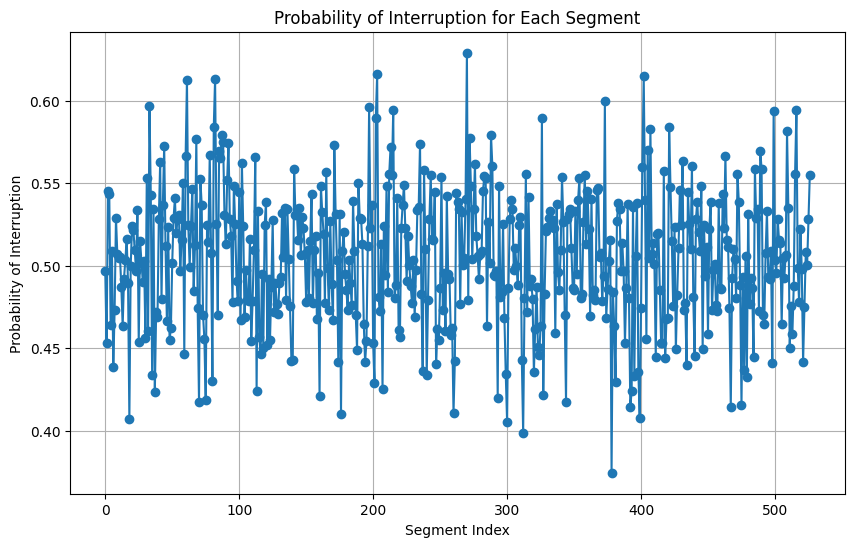

In [5]:
import matplotlib.pyplot as plt
# Visualisierung der Wahrscheinlichkeiten
probs = [prob for _, prob in all_predictions]
plt.figure(figsize=(10, 6))
plt.plot(probs, marker='o')
plt.xlabel('Segment Index')
plt.ylabel('Probability of Interruption')
plt.title('Probability of Interruption for Each Segment')
plt.grid(True)
plt.show()

Nachfolgend habe ich in den gleichen Code von oben etwas angepasst, um Metriken, wie die Accuracy, Precision, Recall und den F1-Score anzeigen zu lassen. Dafür musste ich noch die Daten labeln, was der mit * markierte Code in der folgenden Zelle macht.

In [8]:
import json
import nltk
from nltk.tokenize import sent_tokenize
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import matplotlib.pyplot as plt
import re
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('punkt')

file_path = '/var/lib/private/simonjaned87761/team-04_deprecated/data/opendata_api/modified_texts_with_interruption.json'

with open(file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

data = data[:10]

tokenizer = BertTokenizer.from_pretrained('bert-base-german-cased')
model = BertForSequenceClassification.from_pretrained('bert-base-german-cased')
model.eval()

def predict_interruption(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probabilities[0][1].item()  # Wahrscheinlichkeit für Klasse "Einwurf"

all_predictions = []
true_labels = []  

for entry in data:
    modified_text = entry['modified_text']
    segments = sent_tokenize(modified_text) 

    predictions = []
    for segment in segments:
        if segment.strip():  # Leere Segmente ignorieren
            prob = predict_interruption(segment)
            # * Hier werden die Labels vergeben
            true_label = 1 if '<interruption>' in segment else 0  
            true_labels.append(true_label)
            predictions.append((segment, prob))
    
    all_predictions.extend(predictions)

# Berechnung der Metriken
pred_labels = [1 if prob >= 0.5 else 0 for _, prob in all_predictions]
accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels)
recall = recall_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels)

for sentence, prob in all_predictions:
    print(f"Sentence: {sentence}\nProbability of Interruption: {prob:.2f}\n")


[nltk_data] Downloading package punkt to
[nltk_data]     /var/lib/simonjaned87761/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/var/lib/simonjaned87761/.local/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at bert-base-german-cased were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or wi

Sentence: Sehr geehrter Herr Präsident!
Probability of Interruption: 0.47

Sentence: Sehr geehrte Damen und Herren!
Probability of Interruption: 0.51

Sentence: Verehrte Bürger!
Probability of Interruption: 0.49

Sentence: In diesen Coronazeiten – wir haben es in dieser Woche schon öfter gehört – ist wenig normal.
Probability of Interruption: 0.54

Sentence: Die Bewältigung der Coronakrise hat erhebliche Auswirkungen auf den Bundeshaushalt.
Probability of Interruption: 0.42

Sentence: Besonders davon betroffen ist – kein Wunder – der Bereich des Einzelplans 11, Arbeit und Soziales.
Probability of Interruption: 0.44

Sentence: Der Haushaltsentwurf 2021 für das Bundesministerium für Arbeit und Soziales hat einen Umfang von insgesamt rund 165 Milliarden Euro und ist damit wieder der größte Einzelplan im Bundeshaushalt.
Probability of Interruption: 0.37

Sentence: Vom Entwurf bis zur Bereinigungssitzung wuchs dieser Haushaltsplan auf knapp 1 Milliarde Euro auf.
Probability of Interruption:

Das Ergebnis (unten rechts) ist interessant und bestätigt meine Hypothese. Eine Accuracy von 0,72 bei einem F1-Score von 0,09 deutet auf eine schlechte Performance hin. Die Begründung liegt in folgender Ursache. 

Die Klasse "kein Einwurf" kommt sehr viel häufiger vor als die Klasse "Einwurf". Dadurch kann das Modell durch einfaches Raten der Klasse "kein Einwurf" eine hohe Accuracy erzielen. Der F1-Score ist ja das harmonische Mittel zwischen Precision und Recall und bleibt aufgrund der falschen Vorhersagen entsprechend niedrig.

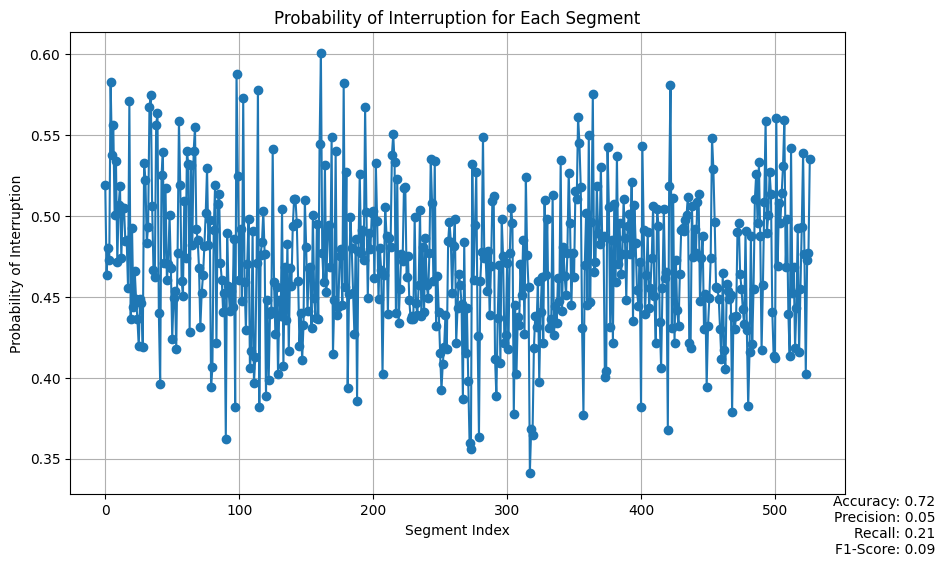

In [7]:
# Visualisierung der Wahrscheinlichkeiten
probs = [prob for _, prob in all_predictions]
plt.figure(figsize=(10, 6))
plt.plot(probs, marker='o')
plt.xlabel('Segment Index')
plt.ylabel('Probability of Interruption')
plt.title('Probability of Interruption for Each Segment')
plt.grid(True)

# Anzeige der Accuracy im Plot
plt.figtext(0.99, 0.01, f'Accuracy: {accuracy:.2f}\nPrecision: {precision:.2f}\nRecall: {recall:.2f}\nF1-Score: {f1:.2f}', horizontalalignment='right')

plt.show()
